## 1️⃣ Import the librairy, Load & clean data

In [4]:
import pandas as pd

df = pd.read_excel("C:/Users/danny/Telco-Customer-Churn-Analysis/Data/Telco-Customer-Churn.xlsx")

In [6]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Convert TotalCharges (classic dataset problem)

In [7]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [8]:
df['TotalCharges'].dtype

dtype('float64')

## Delete the missing lines

In [9]:
df.dropna(inplace = True)

## Encoding the churn

In [10]:
df['Churn_Flag'] = df['Churn'].map({'Yes':1, 'No':0})

In [12]:
df['Churn_Flag'].head(5)

0    0
1    0
2    1
3    0
4    1
Name: Churn_Flag, dtype: int64

## 2️⃣ Create variables

## Seniority groups

In [13]:
df['Tenure_Group'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,100],
    labels=['0-12','13-24','25-48','49+']
)

## high-charge clients

In [14]:
df['High_Monthly_Charge'] = df['MonthlyCharges'].apply(
    lambda x: 'Yes' if x > df['MonthlyCharges'].median() else 'No'
)

## Estimated income

In [15]:
df['Total_Revenue_Estimated'] = df['MonthlyCharges'] * df['tenure']

In [16]:
df['Total_Revenue_Estimated'].head(5)

0      29.85
1    1936.30
2     107.70
3    1903.50
4     141.40
Name: Total_Revenue_Estimated, dtype: float64

## 3️⃣ EDA ESSENTIAL

## Churn rate

In [21]:
churn_rate = df['Churn_Flag'].mean()
print(f"churn rate: {churn_rate:.3%}")

churn rate: 26.578%


## Churn by contract type

In [22]:
df.groupby('Contract')['Churn_Flag'].mean().sort_values(ascending=False)

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn_Flag, dtype: float64

## 📊 Data visualization

## Monthly Contracts vs. Churn

In [24]:
import matplotlib.pyplot as plt

In [25]:
contract_churn = (
    df.groupby('Contract')['Churn_Flag']
    .mean()
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    0.427097
One year          0.112772
Two year          0.028487
Name: Churn_Flag, dtype: float64

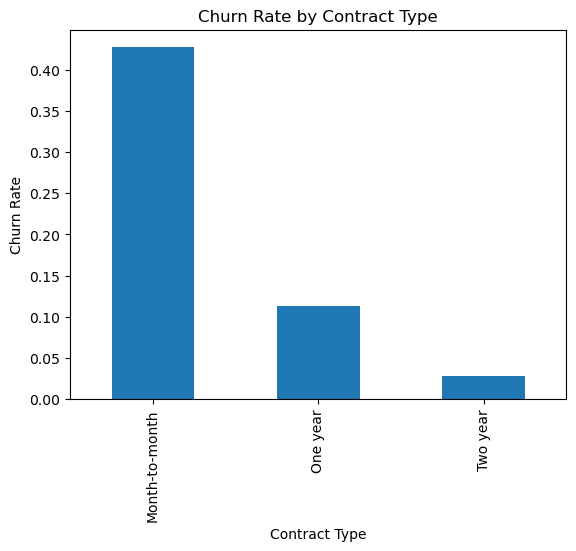

In [26]:
contract_churn.plot(kind='bar')
plt.title("Churn Rate by Contract Type")
plt.ylabel("Churn Rate")
plt.xlabel("Contract Type")
plt.show()

### 🔹 Insight 1 - Monthly Contracts and Churn
Customers with **month-to-month** contracts have a significantly higher churn rate than those with annual or bi-annual contracts.

**📉 Business Interpretation:**
The lack of a contractual commitment facilitates short-term cancellations.

**💡 Recommended Action:**
Implement incentives (discounts, free services) to encourage customers to switch to longer-term contracts.

## 📊 New clients (Tenure Group)

In [27]:
tenure_churn = (
    df.groupby('Tenure_Group')['Churn_Flag']
    .mean()
    .sort_values(ascending=False)
)

tenure_churn

C:\Users\danny\AppData\Local\Temp\ipykernel_25140\3999445796.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Tenure_Group')['Churn_Flag']


Tenure_Group
0-12     0.476782
13-24    0.287109
25-48    0.203890
49+      0.095132
Name: Churn_Flag, dtype: float64

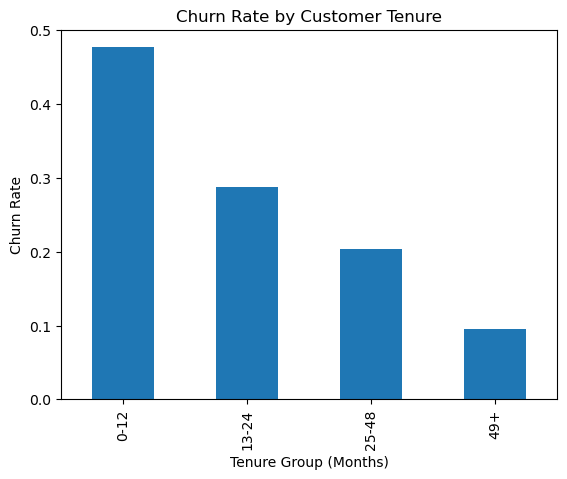

In [28]:
tenure_churn.plot(kind='bar')
plt.title("Churn Rate by Customer Tenure")
plt.ylabel("Churn Rate")
plt.xlabel("Tenure Group (Months)")
plt.show()

### 🔹 Insight 2 - New Customers and Churn
Customers with **0 to 12 months of service** have the highest churn rate.

Churn gradually decreases with increasing customer tenure.

**📉 Business Interpretation:**
The first few months of subscription are critical for customer retention.

**💡Recommended Action:**
Strengthen customer onboarding and offer early loyalty incentives.

## 📊 Internet Services

In [29]:
internet_churn = (
    df.groupby('InternetService')['Churn_Flag']
    .mean()
    .sort_values(ascending=False)
)
internet_churn

InternetService
Fiber optic    0.418928
DSL            0.189983
No             0.074342
Name: Churn_Flag, dtype: float64

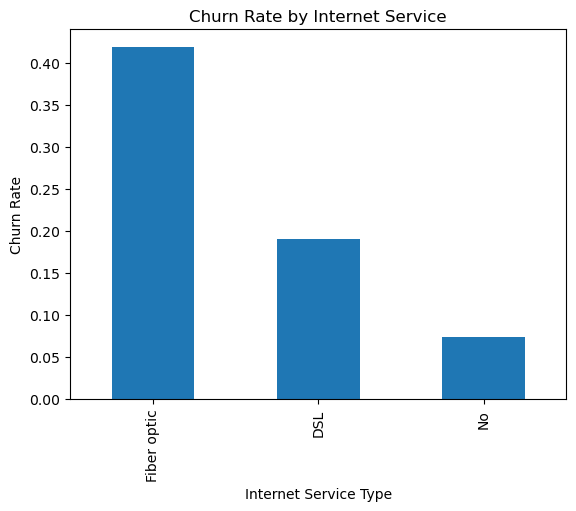

In [30]:
internet_churn.plot(kind='bar')
plt.title("Churn Rate by Internet Service")
plt.ylabel("Churn Rate")
plt.xlabel("Internet Service Type")
plt.show()

### 🔹 Insight 3 - Internet Services and Churn
Customers using **Fiber Optic** service have a higher churn rate than those using DSL or those without internet service.

**📉 Business Interpretation:** Expectations for quality and price are higher for premium services.

**💡 Recommended Action:** Improve perceived service quality and adjust pricing policy for fiber customers.

## 📊 Payment methods

In [31]:
payment_churn = (
    df.groupby('PaymentMethod')['Churn_Flag']
    .mean()
    .sort_values(ascending=False)
)

payment_churn

PaymentMethod
Electronic check             0.452854
Mailed check                 0.192020
Bank transfer (automatic)    0.167315
Credit card (automatic)      0.152531
Name: Churn_Flag, dtype: float64

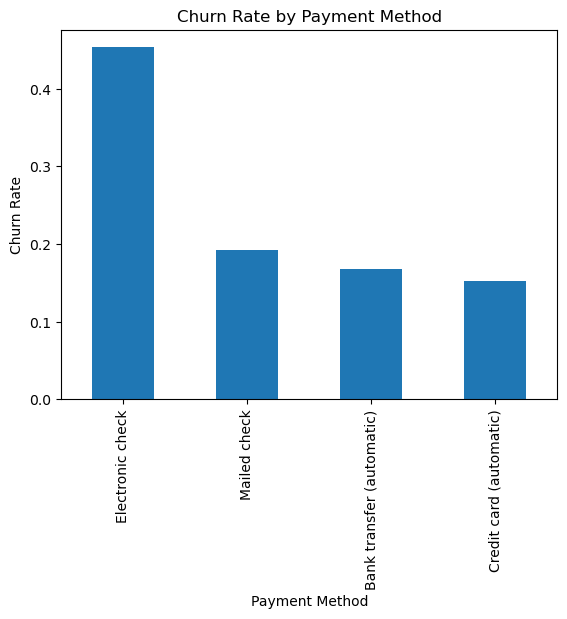

In [32]:
payment_churn.plot(kind='bar')
plt.title("Churn Rate by Payment Method")
plt.ylabel("Churn Rate")
plt.xlabel("Payment Method")
plt.show()

### 🔹 Insight 4 - Payment Methods and Churn
Customers using **Electronic Check** experience significantly higher churn than those using automated payment methods.

**📉 Business Interpretation:**
Manual payments increase friction and make it easier for customers to cancel their subscriptions.

**💡 Recommended Action:**
Encourage the adoption of automated payments through financial incentives.

## 🔹 Insight 5 — Financial Impact of Churn

Churn represents a significant revenue loss, especially for high-billing customers.

Even a modest reduction in churn would have a direct impact on profitability.

**📉 Business Interpretation:**
Customer retention is more profitable than acquiring new customers.

**💡 Recommended Action:**
Prioritize retention efforts for high-value, high-risk segments.

## 📌 Summary of Key Churn Factors
Churn is primarily influenced by:
- **monthly contracts**
- **new customers**
- certain **premium internet services**
- **manual payment methods**

A retention strategy targeting these segments would significantly reduce revenue losses.

## 📊 Conclusion

The analysis shows that churn is not random: it is strongly linked to customer tenure, contract type, billing amount, and payment method. Targeted actions aimed at new, high-value customers could significantly reduce financial losses.

In [35]:
df.to_excel("cleaned_telco_churn.xlsx", index=False)